# Week 3 (Start) — Model Evaluation & Hyperparameter Tuning (Student Notebook)

This starter notebook mirrors the instructor notebook but contains guided TODOs and explanatory cells before every code cell.
Follow the instructions in each markdown cell and implement the code in the following code cell.

## 0. Setup: Imports and dataset loading
In the code cell below import the libraries you'll need (numpy, pandas, matplotlib, seaborn, scikit-learn helpers) and load the Iris dataset into a DataFrame.
- Hint: use `load_iris(as_frame=True)` and create `X` (features) and `y` (target).

In [1]:
# Import libraries and load Iris dataset
# Example hints (remove or edit as you implement):
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris


# Load iris dataset as DataFrame
iris = load_iris(as_frame=True)
df = iris.frame.copy()
# Ensure we have a human-friendly class name column
df['target_name'] = df['target'].map(dict(enumerate(iris.target_names)))
X = df[iris.feature_names]
y = df['target']
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target target_name  
0       0      setosa  
1       0      setosa  
2       0      setosa  
3       0      setosa  
4       0      setosa  


## 1. Exploratory Data Analysis (EDA)
Inspect the dataset: compute descriptive statistics, check class balance, and print any missing values.
Write code to display `df.describe().T`, `y.value_counts()` and a check for nulls.

In [2]:
# EDA - statistics, class counts, missing values
print(df.describe().T)
print(y.value_counts())
print(df.isnull().sum())

                   count      mean       std  min  25%   50%  75%  max
sepal length (cm)  150.0  5.843333  0.828066  4.3  5.1  5.80  6.4  7.9
sepal width (cm)   150.0  3.057333  0.435866  2.0  2.8  3.00  3.3  4.4
petal length (cm)  150.0  3.758000  1.765298  1.0  1.6  4.35  5.1  6.9
petal width (cm)   150.0  1.199333  0.762238  0.1  0.3  1.30  1.8  2.5
target             150.0  1.000000  0.819232  0.0  0.0  1.00  2.0  2.0
target
0    50
1    50
2    50
Name: count, dtype: int64
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
target_name          0
dtype: int64


## 2. Data Visualization
Create visualizations to help understand feature relationships and correlations.
- In the next code cell produce a seaborn pairplot (hint: use `sns.pairplot`) and a correlation heatmap.

<Figure size 800x600 with 0 Axes>

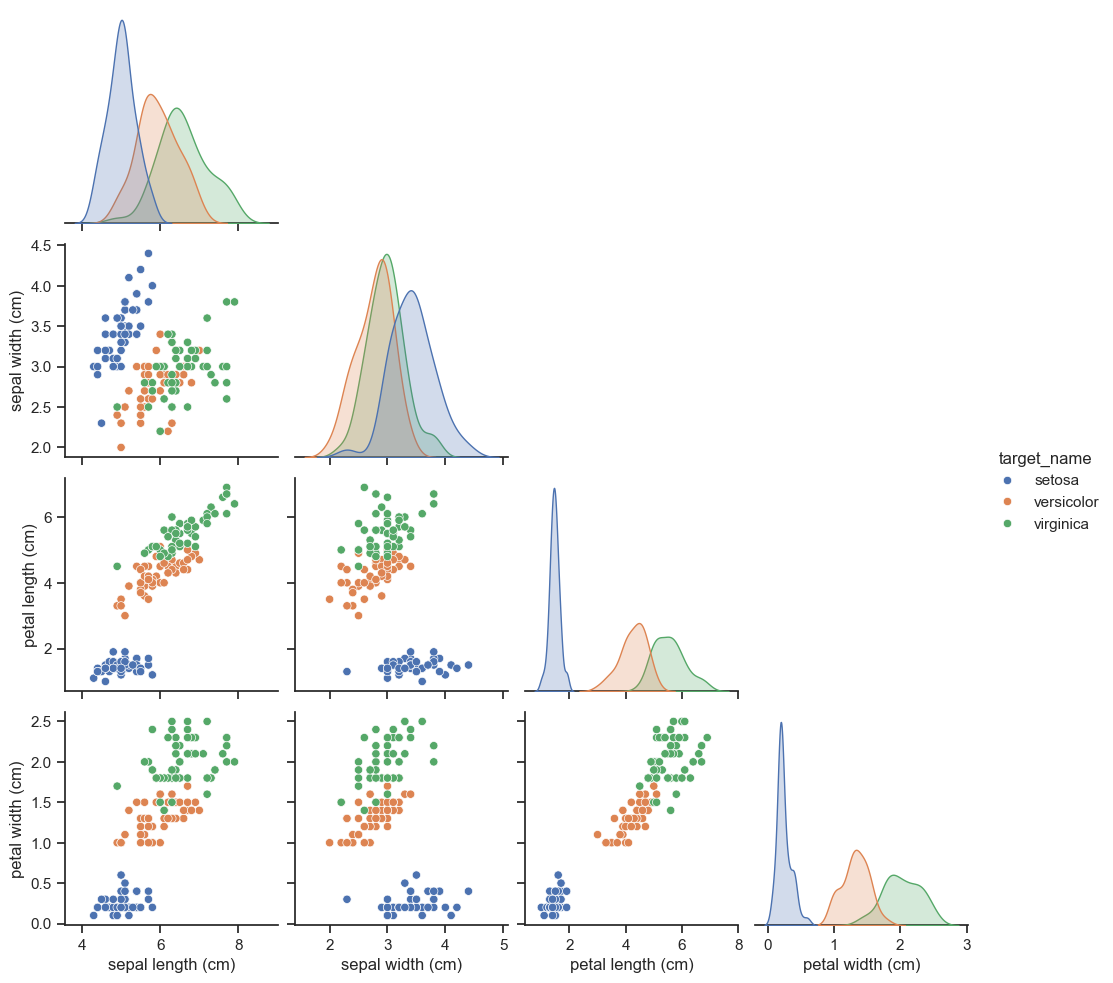

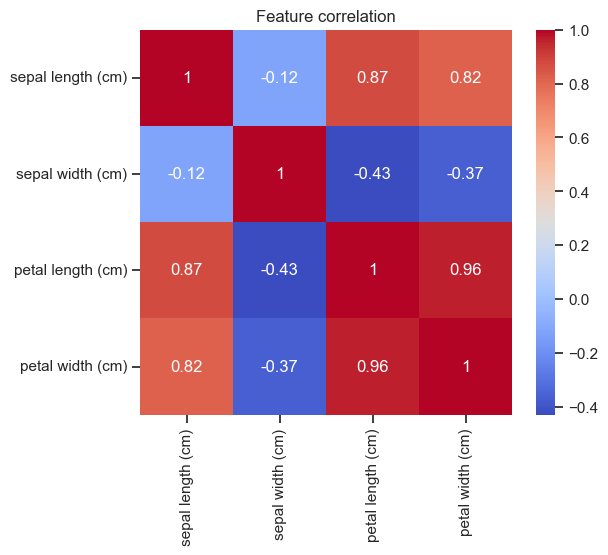

In [3]:
# Create pairplot and correlation heatmap
sns.set(style='ticks')
plt.figure(figsize=(8,6))
sns.pairplot(df, vars=iris.feature_names, hue='target_name', corner=True)
plt.show()

# Correlation heatmap for numeric features
corr = X.corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature correlation')
plt.show()

## 3. Feature Engineering / PCA (optional)
Standardize the features and run PCA (2 components). Visualize the 2D projection colored by class.
- Implement scaling with `StandardScaler` and `PCA(n_components=2)`.

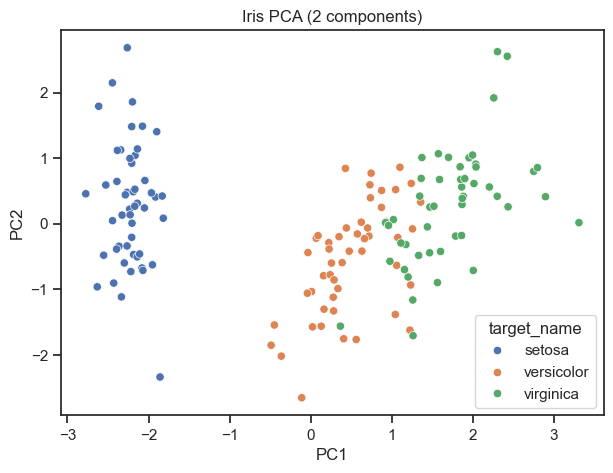

In [4]:
# Scale features and run PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot the two principal components colored by target_name
pc_df = pd.DataFrame(X_pca, columns=['PC1','PC2'])
pc_df['target'] = y.values
pc_df['target_name'] = pc_df['target'].map(dict(enumerate(iris.target_names)))
plt.figure(figsize=(7,5))
sns.scatterplot(data=pc_df, x='PC1', y='PC2', hue='target_name', palette='deep')
plt.title('Iris PCA (2 components)')
plt.show()

## 4. Data Preparation (train/test split and scaling)
Split the data into train and test sets (stratify by label). Then fit a scaler on the training set and transform both training and test sets.
- Use `train_test_split(..., stratify=y, random_state=42)` and `StandardScaler`.

In [5]:
#  train/test split and scaling
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

Train shape: (120, 4) Test shape: (30, 4)


## 5. Baseline Models: Train & Evaluate
Train two baseline models (Logistic Regression and Random Forest).
- Fit models on the training data, predict on the test set, and compute Accuracy, Precision, Recall, F1, and show a confusion matrix.

Logistic Regression classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.86      0.60      0.71        10
           2       0.69      0.90      0.78        10

    accuracy                           0.83        30
   macro avg       0.85      0.83      0.83        30
weighted avg       0.85      0.83      0.83        30



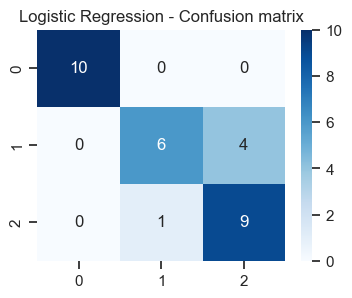

Random Forest classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.82      0.90      0.86        10
           2       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



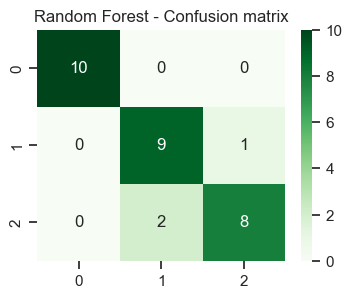

In [7]:
# Train baseline models and evaluate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

log = LogisticRegression(solver='liblinear', random_state=42)
rf = RandomForestClassifier(random_state=42)

log.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)

# Make predictions with Logistic Regression
yhat_log = log.predict(X_test_scaled)

# Evaluate Logistic Regression
print('Logistic Regression classification report:')
print(classification_report(y_test, yhat_log))
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, yhat_log), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression - Confusion matrix')
plt.show()

# Evaluate Random Forest
yhat_rf = rf.predict(X_test_scaled)
print('Random Forest classification report:')
print(classification_report(y_test, yhat_rf))
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, yhat_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest - Confusion matrix')
plt.show()

## 6. Cross-Validation Exercises
Try K-Fold, StratifiedKFold, and Leave-One-Out CV on one of the models. Report the cross-validated F1 scores.
- Use `cross_val_score` and appropriate CV splitter objects.

In [8]:
# TODO: Cross-validation experiments
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold, LeaveOneOut


## 7. Hyperparameter Tuning
In the following exercises you will implement Grid Search and Randomized Search to tune model hyperparameters.
- For the synthetic dataset: tune Logistic Regression and compare F1 and ROC before/after.
- For the Breast Cancer dataset: tune Random Forest using RandomizedSearchCV and compare baseline vs tuned.
Implement the tuning steps in the two code cells that follow.

In [9]:
# TODO: Hyperparameter tuning (synthetic)
from sklearn.datasets import load_iris, load_breast_cancer, make_classification

# Steps:
# 1) Create an imbalanced synthetic dataset using make_classification
X_syn, y_syn = make_classification(n_samples=2000, n_features=10, n_informative=3, n_redundant=1, n_clusters_per_class=1, weights=[0.9,0.1], flip_y=0.01, random_state=42)

# 2) Split into train/test, fit a baseline LogisticRegression
# 3) Define a param grid and run GridSearchCV (scoring='f1')
# 4) Refit on the best params and compare precision/recall/f1 and ROC AUC
# Hints: from sklearn.datasets import make_classification; GridSearchCV; roc_auc_score; precision_recall_fscore_support

In [ ]:
# TODO: Hyperparameter tuning (Breast Cancer)
# Steps:
# 1) Load breast cancer dataset (load_breast_cancer)
# 2) Train baseline RandomForest and record metrics
# 3) Define parameter distributions and run RandomizedSearchCV (scoring='f1')
# 4) Evaluate tuned model and compare ROC/AUC and classification report
# Hints: RandomizedSearchCV, scipy.stats.randint for integer ranges

## 8. Overfitting vs Underfitting
Create an underfit and overfit random forest (vary `n_estimators` and `max_depth`) and compare training vs test scores.
- Implement three models: underfit, balanced (from tuning), and overfit. Print training and test accuracy for each.

In [ ]:
# TODO: Demonstrate overfitting vs underfitting
# e.g. rf_underfit = RandomForestClassifier(n_estimators=5, max_depth=2)
rf_overfit = RandomForestClassifier(n_estimators=200, max_depth=None)
print(train_score, test_score)

### Exercise A (Synthetic): Questions
1. After tuning, which hyperparameters changed and how did F1 and AUC change?
2. Which curve (ROC or Precision-Recall) do you think is more informative for this imbalanced problem and why?

### Exercise B (Breast Cancer): Questions
1. Compare baseline vs tuned model: which metrics improved and which did not?
2. If you wanted to prioritize reducing false negatives (missing malignant cases), which metric would you optimize and how would you change the search?